In [3]:
import pandas as pd
from sklearn.mixture import GaussianMixture
import pickle
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
with open('../../data/nifty_ts2vec_embeddings.pkl', 'rb') as f:
    df = pickle.load(f)

In [5]:
embeddings = df.drop("Close", axis=1)
embeddings

,0,1,2,3,4,5,6,7,8,9,...,54,55,56,57,58,59,60,61,62,63
Date,,,,,,,,,,,,,,,,,,,,,
2008-06-05 00:00:00+05:30,0.000000,0.094707,0.000000,0.086095,0.000000,0.052627,0.000000,0.034146,0.049268,0.079448,...,0.022316,0.000000,0.007209,0.042414,0.000000,0.000000,0.097714,0.014177,0.101710,0.000000
2008-06-06 00:00:00+05:30,0.000000,0.096463,0.000000,0.093592,0.000000,0.055477,0.000000,0.038427,0.048164,0.072977,...,0.026902,0.000000,0.004996,0.039518,0.000000,0.000000,0.092051,0.016242,0.101359,0.000000
2008-06-09 00:00:00+05:30,0.000000,0.097814,0.000000,0.100934,0.000000,0.060673,0.000000,0.042575,0.046727,0.065568,...,0.032963,0.000000,0.002542,0.034720,0.000000,0.000000,0.085397,0.017465,0.100786,0.000000
2008-06-10 00:00:00+05:30,0.000000,0.099855,0.000000,0.104100,0.000000,0.071059,0.000000,0.047309,0.046517,0.058178,...,0.038096,0.000000,0.001713,0.030261,0.000000,0.000000,0.080686,0.019027,0.099659,0.000000
2008-06-11 00:00:00+05:30,0.000000,0.100483,0.000000,0.105155,0.000000,0.084748,0.000000,0.052642,0.045687,0.050810,...,0.045469,0.000058,0.000870,0.026759,0.000000,0.000000,0.075993,0.020184,0.097661,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-09-12 00:00:00+05:30,0.150253,0.171876,0.110617,0.016477,0.000274,0.000000,0.104171,0.077467,0.020435,0.000000,...,0.041521,0.073654,0.000000,0.000000,0.025725,0.050502,0.000000,0.019644,0.066028,0.036041
2025-09-15 00:00:00+05:30,0.140572,0.171512,0.102708,0.012511,0.000518,0.000000,0.113352,0.073049,0.019066,0.000000,...,0.039853,0.072866,0.000000,0.000000,0.025318,0.053611,0.000000,0.021749,0.061992,0.034028
2025-09-16 00:00:00+05:30,0.128521,0.175892,0.093519,0.008835,0.000000,0.000000,0.121123,0.067323,0.016315,0.000000,...,0.037340,0.075898,0.000000,0.000000,0.024032,0.058974,0.000000,0.025540,0.057928,0.034247


In [6]:
def build_df(dataframe, start_date, days):
    df_ = dataframe.copy()

    # Ensure datetime index
    if not pd.api.types.is_datetime64_any_dtype(df_.index):
        df_.index = pd.to_datetime(df_.index)

    idx_tz = getattr(df_.index, "tz", None)

    start = pd.to_datetime(start_date)
    if idx_tz is not None:
        start = start.tz_localize(idx_tz) if start.tzinfo is None else start.tz_convert(idx_tz)

    end = start + pd.Timedelta(days=days)

    mask = (df_.index >= start) & (df_.index <= end)
    tdf = df_.loc[mask].copy()

    X = tdf.drop("Close", axis=1).to_numpy()
    return tdf, X

In [7]:
slice_df, slice_embeddings = build_df(df, "2020-01-01", 252)

In [8]:
gmm = GaussianMixture(n_components=3, covariance_type="full", max_iter=2000).fit(slice_embeddings)
labels = gmm.predict(slice_embeddings)

In [9]:
# centroids
centroids = gmm.means_
centroid_df = pd.DataFrame(centroids, columns=slice_df.columns.drop("Close"))

In [14]:
centroid_df

,0,1,2,3,4,5,6,7,8,9,...,54,55,56,57,58,59,60,61,62,63
0,0.000000,0.138449,0.000000,0.032408,4.985049e-37,0.102603,0.000007,0.004715,0.024804,0.023577,...,0.103762,0.076971,0.000000,0.000652,0.061675,0.000000,0.000800,0.044294,0.015093,0.000000
1,0.003795,0.050110,0.031441,0.119959,4.481137e-03,0.007528,0.061733,0.084796,0.009650,0.031389,...,0.037191,0.040983,0.005773,0.039281,0.095999,0.030039,0.001013,0.012110,0.029965,0.036673
2,0.000393,0.007400,0.000131,0.129303,1.247837e-03,0.142027,0.000000,0.021921,0.034029,0.016055,...,0.015717,0.012034,0.000000,0.000097,0.000000,0.000000,0.000000,0.010686,0.106694,0.039498


In [38]:
probs = gmm.predict_proba(slice_embeddings)

In [39]:
probs_df = pd.DataFrame(
    probs,
    index=slice_df.index,
    columns=[f'Cluster_{i}_Prob' for i in range(probs.shape[1])]
)
probs_df["Cluster"] = labels
probs_df["Close"] = df["Close"]

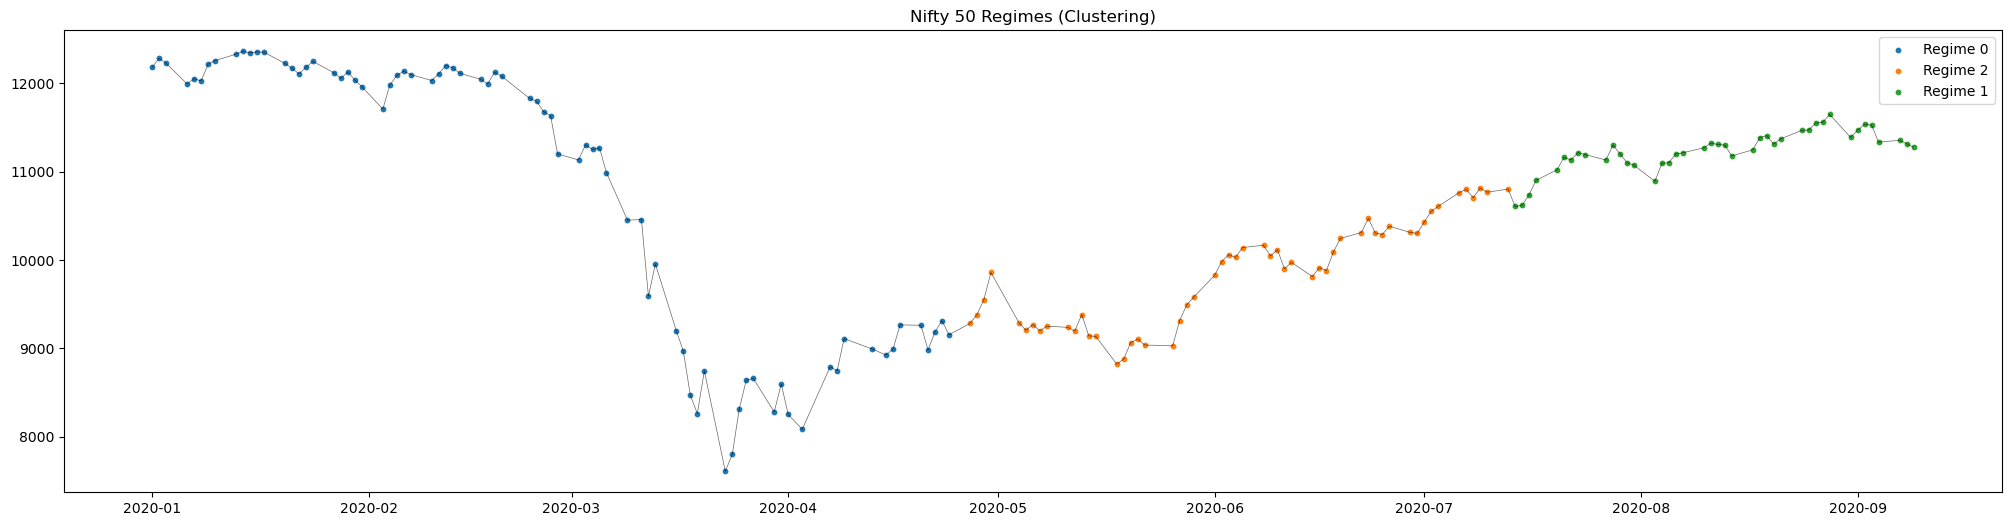

In [40]:
plt.figure(figsize=(25,6))

for c in probs_df['Cluster'].dropna().unique():
    mask = probs_df['Cluster'] == c
    plt.scatter(probs_df.index[mask], probs_df['Close'][mask], label=f"Regime {c}", s=10)
plt.plot(probs_df.index, probs_df['Close'], color='black', linewidth=0.5, alpha=0.6)
plt.title("Nifty 50 Regimes (Clustering)")
plt.legend()
plt.show()

In [41]:
probs_df

,Cluster_0_Prob,Cluster_1_Prob,Cluster_2_Prob,Cluster,Close
Date,,,,,
2020-01-01 00:00:00+05:30,1.0,0.0,0.0,0,12182.500000
2020-01-02 00:00:00+05:30,1.0,0.0,0.0,0,12282.200195
2020-01-03 00:00:00+05:30,1.0,0.0,0.0,0,12226.650391
2020-01-06 00:00:00+05:30,1.0,0.0,0.0,0,11993.049805
2020-01-07 00:00:00+05:30,1.0,0.0,0.0,0,12052.950195
...,...,...,...,...,...
2020-09-03 00:00:00+05:30,0.0,1.0,0.0,1,11527.450195
2020-09-04 00:00:00+05:30,0.0,1.0,0.0,1,11333.849609
2020-09-07 00:00:00+05:30,0.0,1.0,0.0,1,11355.049805


<Axes: xlabel='Cluster_0_Prob', ylabel='Count'>

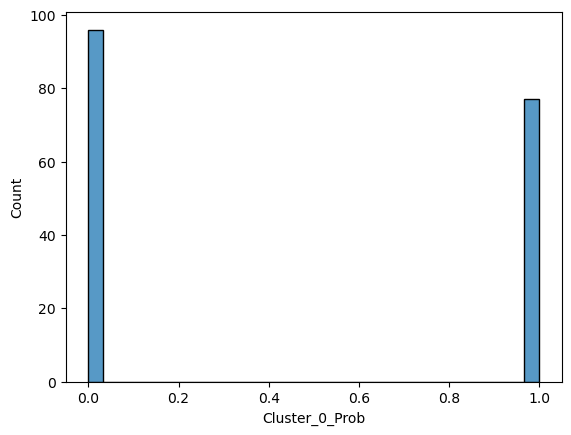

In [ ]:
sns.histplot(data=probs_df, x='Cluster_0_Prob', bins=30)

<Axes: xlabel='Cluster_1_Prob', ylabel='Count'>

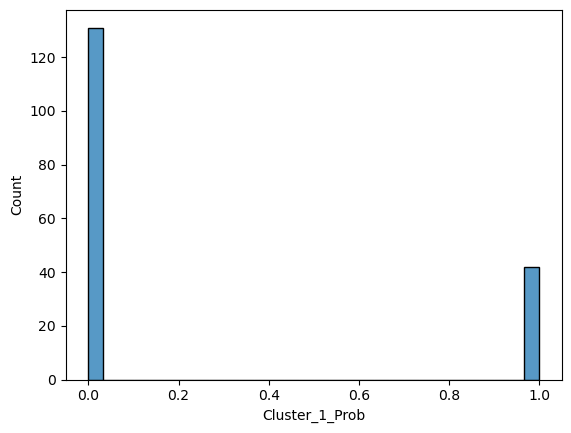

In [46]:
sns.histplot(data=probs_df, x='Cluster_1_Prob', bins=30)


<Axes: xlabel='Cluster_2_Prob', ylabel='Count'>

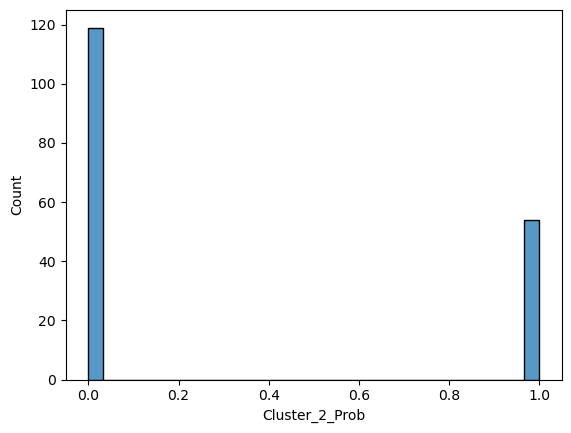

In [47]:
sns.histplot(data=probs_df, x='Cluster_2_Prob', bins=30)